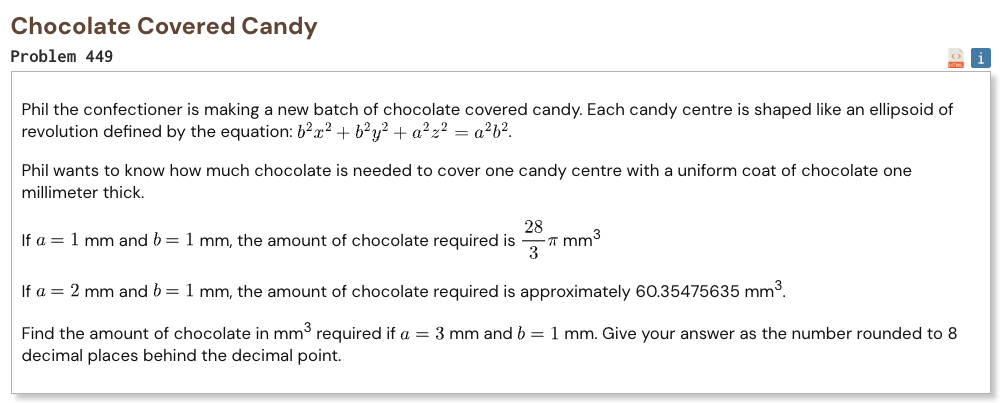

## Initial approach

-   rewrite the ellipsoid so `a` is the horizontal radius and `b` is the vertical radius
-   describe the outside surface of the candy centre with one angle
-   at every point find the outward unit normal of the ellipsoid
-   move each surface point one millimeter along that normal to create the chocolate outer surface
-   rotate this new profile around the vertical axis to get the coated candy volume
-   integrate the volume of the outer body numerically with scipy
-   subtract the original ellipsoid volume to leave only the chocolate volume
-   the same calculation reproduces the given `a = 2`, `b = 1` check value

In [1]:
%%time

import math
from scipy.integrate import quad

a = 3.0
b = 1.0
thickness = 1.0

def integrand(theta):
    s = math.sin(theta)
    c = math.cos(theta)

    normal_length = math.sqrt(
        (s / a) ** 2
        + (c / b) ** 2
    )

    radius = (
        a * s
        + thickness * (s / a) / normal_length
    )

    normal_derivative = (
        s
        * c
        * (1 / a**2 - 1 / b**2)
        / normal_length
    )

    dz = (
        -b * s
        + thickness
        * (
            (-s / b) / normal_length
            - (c / b)
            * normal_derivative
            / normal_length**2
        )
    )

    return math.pi * radius**2 * (-dz)

outer_volume = quad(
    integrand,
    0,
    math.pi,
    epsabs=1e-12,
    epsrel=1e-12
)[0]

inner_volume = 4 * math.pi * a**2 * b / 3

result = outer_volume - inner_volume

print("Result:", round(result, 8))

Result: 103.37870096
CPU times: user 1.8 s, sys: 183 ms, total: 1.98 s
Wall time: 470 ms
